In [1]:
import IPython,ipywidgets as widgets

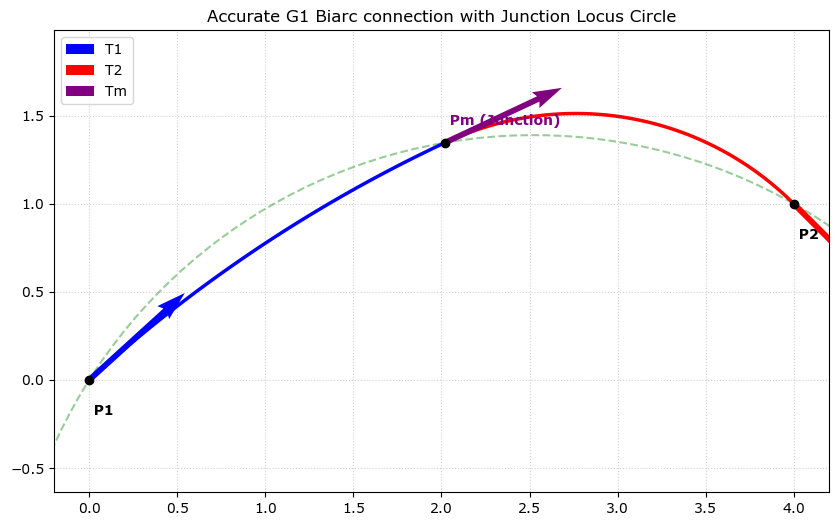

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import cmath
rad=(-1)**(1/cmath.pi)
def compute_biarc_p(P: complex, w0: float) -> float:
    """
    Computes the biarc family parameter p for a given point P (x + iy) 
    and lens half-width angle w0 according to Equation (33).
    """
    # 1. Phase angle of the lens as a complex unit vector
    E2 = rad**(2* w0)
    
    # 2. Conformal Möbius mapping to the W-plane
    W = (P - 1) / (P + 1)
    
    # 3. Branch execution based on the sign of the imaginary part
    if P.imag >= 0:
        p_complex = (1 - E2) / (E2 * W - W.conjugate())
    else:
        p_complex = (E2 * (1 / W) - (1 / W.conjugate())) / (1 - E2)
        
    # The result is strictly a real number; extract the real part
    return p_complex.real
    
import cmath

def calculate_biarc_geometry_complex(p: float, Ta: complex, Tb: complex):
    """
    Calculates the biarc geometry using purely complex vector math.
    
    Inputs:
        p: family parameter (float)
        Ta: complex unit vector of the start tangent (e^(i*alpha0))
        Tb: complex unit vector of the end tangent (e^(i*beta0))
    """
    # --- 1. Compute the Complex Junction Point J ---
    # In complex terms, Kurnosenko's lens bisector phasor is sqrt(Ta * Tb.conjugate())
    # F scales perfectly into a clean inner product variant:
    F = p**2 + p * (Ta * Tb.conjugate() + 1).real + 1.0
    
    if abs(F) < 1e-12:
        raise ValueError("Parameter p matches a discontinuous biarc boundary.")
    
    # Elegant complex projection mapping the poles A(-1) and B(1) to J
    J = ((p**2 - 1.0) + 1j * p * (Ta - Tb)) / F

    # --- 2. Compute the Tangent Phasor at the Junction (Tj) ---
    # Using complex square roots avoids half-angle tan arithmetic entirely
    num = p * cmath.sqrt(Ta) + cmath.sqrt(Tb)
    
    # Squaring the normalized numerator naturally recovers the full exit tangent
    Tj = -(num / abs(num))**2
    
    # --- 3. Compute Arc Heading Changes (theta1, theta2) ---
    # Relative rotations are just the phase angles of the phasor quotients
    theta1 = cmath.phase(Tj / Ta)
    theta2 = cmath.phase(Tb / Tj)
    
    return {
        "junction": J,
        "tangent_at_junction": Tj,       # Returned as a complex unit vector
        "arc1_heading_change": theta1,    # In radians, naturally in (-pi, pi]
        "arc2_heading_change": theta2     # In radians, naturally in (-pi, pi]
    }
    
def find_arc_center_radius(p_start, t_start, p_end):
        # Center is intersection of tangent normal and chord perpendicular 
        t_start/=abs(t_start)
        chord = p_end - p_start
        l_chord = abs(chord)
        e_chord = chord/l_chord
        phi=e_chord/t_start
        r=0.5*l_chord/phi.imag
        #print(f'{phi=}, {l_chord=}')
        return p_start+r*t_start*1j, r

def compute_biarc_original_hybrid(p1, t1, p2, t2):
    #p1,p2,t1,t2 = (complex(*p) for p in (p1,p2,t1,t2))
    t1/= abs(t1)
    t2/= abs(t2)

    v = p2 - p1
    v_dot_t1 = (v*t1.conjugate()).real
    v_dot_t2 = (v*t2.conjugate()).real
    t1_dot_t2 = (t1*t2.conjugate()).real
    
    # 1. Revert to the original symmetric weight formula
    a = 2.0 * (1.0 - t1_dot_t2)
    b = 2.0 * (v_dot_t1 + v_dot_t2)
    c = -(v*v.conjugate()).real
    
    discriminant = b**2 - 4*a*c
    d1 = (-b + np.sqrt(discriminant)) / (2.0 * a)
    d2 = d1

    # Exact original formula for the junction point
    pm = p1 + d1 * t1 + (p2 - p1 - d1*t1 - d2*t2) / 2.0 
    

    # 2. Independently compute Arc 1 and Arc 2 properties from Pm
    c1, r1 = find_arc_center_radius(p1, t1, pm)
    c2, r2 = find_arc_center_radius(p2, -t2, pm) # Path arriving at P2 along t2
    
    # Calculate the continuous joint tangent at Pm
    v_pm = pm - c1
    tm= v_pm/r1*1j
     
    return p1, pm, p2, c1, r1, c2, r2, t1, t2, tm

def get_arc_points(center, p_start, p_end, t_start, num_points=100):
    
    v_start = p_start - center
    v_end = p_end - center
    phi=v_end/v_start
    dphi=phi**(1/num_points)
    #print (f'{dphi=}')
    v=v_start
    yield center+v_start
    for i in range(num_points):
        v_start*=dphi
        yield center+v_start
        
    
def find_circle(p1: complex, p2: complex, p3: complex):
    # Calculate the cyclic differences
    d1 = p2 - p3
    d2 = p3 - p1
    d3 = p1 - p2
    pd1=p1.conjugate() * d1
    pd2=p2.conjugate() * d2
    pd3=p3.conjugate() * d3
    # Elegant complex algebraic numerator and denominator
    numerator = p1*pd1 + p2*pd2 + p3*pd3
    denominator = pd1 + pd2 + pd3
    
    # If the denominator is 0 (or close to it), the points are collinear
    if abs(denominator) < 1e-12:
        raise ValueError("Points are collinear; a unique circle cannot be formed.")
        
    center = numerator / denominator
    radius = abs(center - p1)
    
    return center, radius


def find_locus_circle(p1, pm, p2):
    p1,pm,p2 = (complex(*p) for p in (p1,pm,p2))
    """Computes the circle passing through the three points P1, Pm, and P2."""
    center,radius=find_circle(p1,pm,p2)
    return [center.real,center.imag],radius

# --- Run & Plot ---
p1_in, t1_in = 0.0+ 0.0j, 1.0+ 1.0j
p2_in, t2_in = 4.0+ 1.0j, 1.0 -1.0j
p1_in, t1_in = 0.0+ 0.0j, 1.1 +1.0j
p2_in, t2_in = 4.0+ 1.0j, 1.0 -1.0j

p1, pm, p2, c1, r1, c2, r2, t1, t2, tm = compute_biarc_original_hybrid(p1_in, t1_in, p2_in, t2_in)
c_locus, r_locus = find_circle(p1, pm, p2)

# Complete locus circle sweep
angles = np.linspace(0, 2 * np.pi, 200)
x_locus = c_locus.real + r_locus * np.cos(angles)
y_locus = c_locus.imag + r_locus * np.sin(angles)

# Plotting
fig1=plt.figure(figsize=(10, 6))

plt.scatter([p1.real, pm.real, p2.real], [p1.imag, pm.imag, p2.imag], color='black', zorder=5)
plt.text(p1.real, p1.imag-0.2, ' P1', fontdict={'weight': 'bold'})
plt.text(pm.real, pm.imag+0.1, ' Pm (Junction)', fontdict={'weight': 'bold', 'color': 'purple'})
plt.text(p2.real, p2.imag-0.2, ' P2', fontdict={'weight': 'bold'})

# Render tangent vectors
plt.quiver(p1.real,p1.imag, t1.real, t1.imag, color='blue', scale=6, zorder=4, label='T1')
plt.quiver(p2.real,p2.imag, t2.real, t2.imag, color='red', scale=6, zorder=4, label='T2')
plt.quiver(pm.real,pm.imag, tm.real, tm.imag, color='purple', scale=6, zorder=4, label='Tm')

plt.axis('equal')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left')
xl=plt.xlim()
yl=plt.ylim()

plt.plot(x_locus, y_locus, 'g--', alpha=0.4, label='Junction Locus Circle')
plt.plot(*zip(*[[p.real,p.imag] for p in get_arc_points(c1, p1, pm, t1)]), 'b-', linewidth=2.5, label='Arc 1 (P1 to Pm)')
plt.plot(*zip(*[[p.real,p.imag] for p in get_arc_points(c2, pm, p2, tm)]), 'r-', linewidth=2.5, label='Arc 2 (Pm to P2)')
plt.xlim(xl)
plt.ylim(yl)
plt.title("Accurate G1 Biarc connection with Junction Locus Circle")
plt.close()
IPython.display.display(fig1)

In [47]:
output1=widgets.Output()
with output1:
    IPython.display.display(fig1)

In [48]:
output1

Output(outputs=({'output_type': 'display_data', 'data': {'text/plain': '<Figure size 1000x600 with 1 Axes>', '…